# Wholesale Customers Clustering Mini Project

## Introduction
In this project, we will group wholesale customers based on their annual spending.

We will compare three clustering algorithms:

1. K-Means
2. DBSCAN
3. Hierarchical Clustering

For simple 2D visualization, we will use two numerical features:

- **Milk**: annual spending on milk products
- **Grocery**: annual spending on grocery products

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

## 2. Load the Dataset

In [37]:
df = pd.read_csv("Wholesale customers data.csv")
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


## 3. Explore the Dataset

In [3]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (440, 8)

Column names:
['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [5]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


### Check for Missing Values

In [6]:
df.isnull().sum()

,0
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


### Observation

- The dataset contains **440 customers**.
- All columns are numerical.
- There are no missing values, so no missing-value treatment is required.

## 4. Select Features

In [7]:
X = df[["Milk", "Grocery"]]
X.head()

,Milk,Grocery
0,9656,7561
1,9810,9568
2,8808,7684
3,1196,4221
4,5410,7198


### Visualize the Original Data

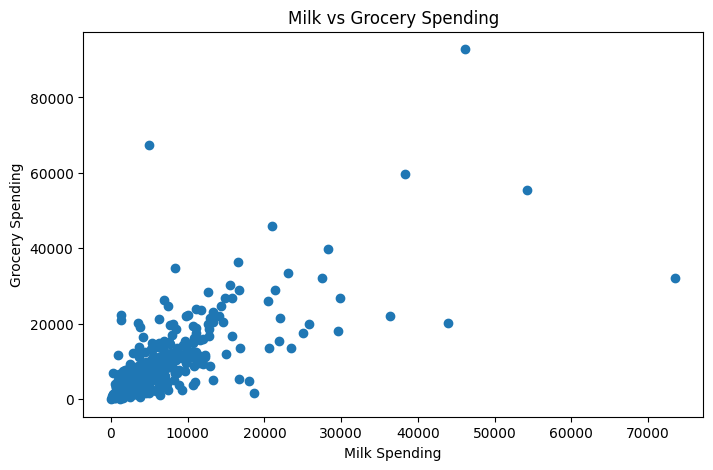

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(X["Milk"], X["Grocery"])

plt.xlabel("Milk Spending")
plt.ylabel("Grocery Spending")
plt.title("Milk vs Grocery Spending")
plt.show()

### Observation

Most customers have low to medium spending, while a small number of customers have very high spending.

## 5. Feature Scaling

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 0.52356777, -0.04111489],
       [ 0.54445767,  0.17031835],
       [ 0.40853771, -0.0281571 ],
       [-0.62401993, -0.3929769 ],
       [-0.05239645, -0.07935618]])

Scaling is important because clustering algorithms use distances between data points. StandardScaler gives both features a similar scale.

## 6. K-Means Clustering

### Use the Elbow Method to Select K

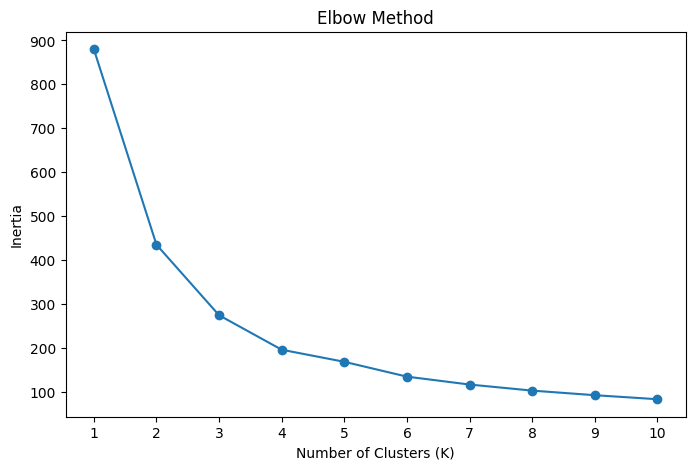

In [10]:
inertia = []
k_values = range(1, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(k_values)
plt.show()

The graph begins to bend around **K = 2**, so we will use two clusters.

In [11]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = kmeans_labels
print(df["KMeans_Cluster"].value_counts().sort_index())

KMeans_Cluster
0    393
1     47
Name: count, dtype: int64


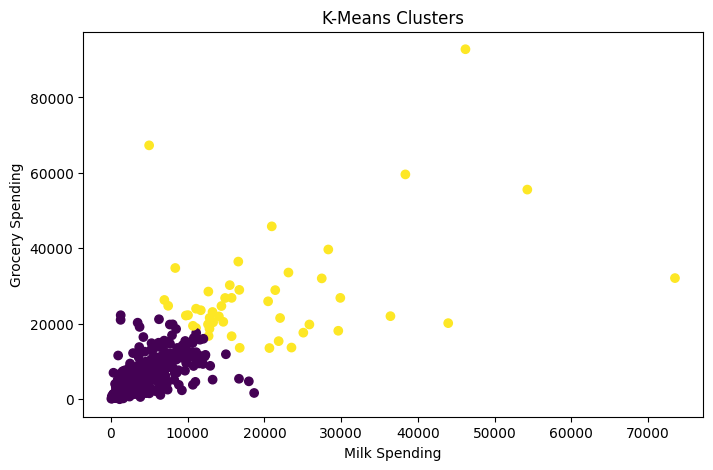

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(X["Milk"], X["Grocery"], c=kmeans_labels)
plt.xlabel("Milk Spending")
plt.ylabel("Grocery Spending")
plt.title("K-Means Clusters")
plt.show()

In [13]:
kmeans_score = silhouette_score(X_scaled, kmeans_labels)
print("K-Means Silhouette Score:", round(kmeans_score, 3))

K-Means Silhouette Score: 0.706


### K-Means Observation

K-Means separated the customers into two groups. One cluster contains most customers with lower spending, while the other contains customers with higher Milk and Grocery spending.

## 7. DBSCAN Clustering

In [35]:
dbscan_results = []

for eps in [0.4, 0.5, 0.6, 0.7]:
    for min_samples in [4, 5, 6]:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X_scaled)

        number_of_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        number_of_noise = int(np.sum(labels == -1))

        if number_of_clusters > 1:
            non_noise_mask = labels != -1
            score = silhouette_score(
                X_scaled[non_noise_mask],
                labels[non_noise_mask]
            )
            score = round(score, 3)
        else:
            score = np.nan

        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "Clusters": number_of_clusters,
            "Noise Points": number_of_noise,
            "Silhouette Score": score
        })

dbscan_tuning = pd.DataFrame(dbscan_results)
dbscan_tuning

,eps,min_samples,Clusters,Noise Points,Silhouette Score
0,0.4,4,1,29,NaN
1,0.4,5,2,30,0.471
2,0.4,6,1,33,NaN
3,0.5,4,2,18,0.632
4,0.5,5,1,25,NaN
5,0.5,6,1,25,NaN
6,0.6,4,1,15,NaN
7,0.6,5,2,20,0.649
8,0.6,6,1,25,NaN
9,0.7,4,1,12,NaN


In [32]:
dbscan = DBSCAN(eps=0.6, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = dbscan_labels
print(df["DBSCAN_Cluster"].value_counts().sort_index())

DBSCAN_Cluster
-1     20
 0    415
 1      5
Name: count, dtype: int64


In DBSCAN, the label **-1** represents noise or unusual customers that do not belong to a dense cluster.

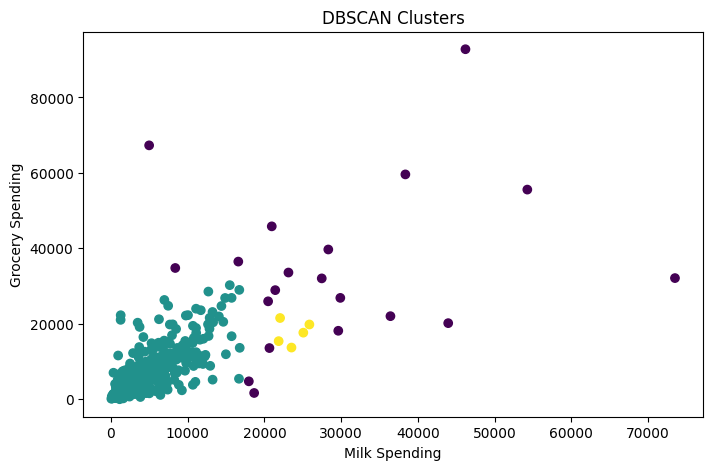

In [31]:
plt.figure(figsize=(8, 5))
plt.scatter(X["Milk"], X["Grocery"], c=dbscan_labels)
plt.xlabel("Milk Spending")
plt.ylabel("Grocery Spending")
plt.title("DBSCAN Clusters")
plt.show()

In [16]:
non_noise = dbscan_labels != -1
number_of_dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

if number_of_dbscan_clusters > 1:
    dbscan_score = silhouette_score(X_scaled[non_noise], dbscan_labels[non_noise])
    print("DBSCAN Silhouette Score:", round(dbscan_score, 3))
else:
    dbscan_score = np.nan
    print("Silhouette Score cannot be calculated because DBSCAN found fewer than two clusters.")

print("Number of DBSCAN clusters:", number_of_dbscan_clusters)
print("Number of noise points:", sum(dbscan_labels == -1))

DBSCAN Silhouette Score: 0.649
Number of DBSCAN clusters: 2
Number of noise points: 20


### DBSCAN Observation

DBSCAN identified dense customer groups and also marked some unusual customers as noise. It is more sensitive to the `eps` and `min_samples` values.

## 8. Hierarchical Clustering

### Dendrogram

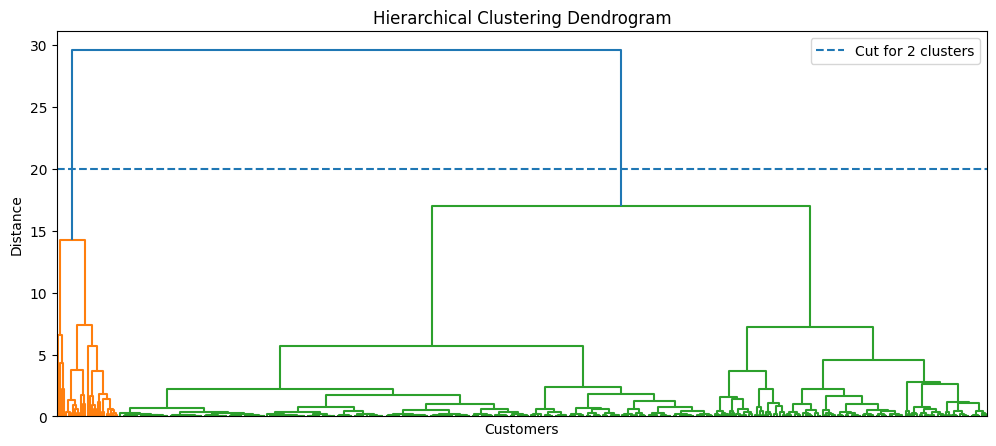

In [34]:
linked_data = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(linked_data, no_labels=True)
plt.axhline(y=20, linestyle="--", label="Cut for 2 clusters")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram")
plt.legend()
plt.show()

Based on the dendrogram, we will choose **two clusters**.

In [18]:
hierarchical = AgglomerativeClustering(n_clusters=2, linkage="ward")
hierarchical_labels = hierarchical.fit_predict(X_scaled)

df["Hierarchical_Cluster"] = hierarchical_labels


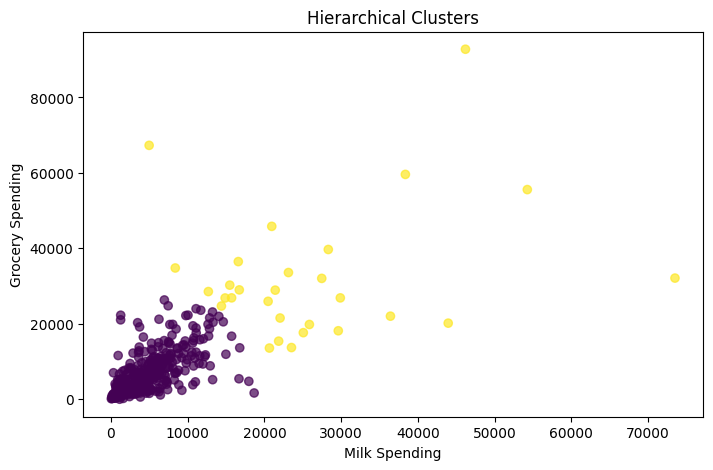

In [19]:
plt.figure(figsize=(8, 5))
plt.scatter(X["Milk"], X["Grocery"], c=hierarchical_labels, alpha=0.7)
plt.xlabel("Milk Spending")
plt.ylabel("Grocery Spending")
plt.title("Hierarchical Clusters")
plt.show()

In [20]:
hierarchical_score = silhouette_score(X_scaled, hierarchical_labels)
print("Hierarchical Silhouette Score:", round(hierarchical_score, 3))

Hierarchical Silhouette Score: 0.746


### Hierarchical Clustering Observation

Hierarchical Clustering also separated the customers into two groups. Its result is similar to K-Means, but it builds clusters step by step based on distance.

## 9. Compare the Algorithms

In [21]:
comparison = pd.DataFrame({
    "Algorithm": ["K-Means", "DBSCAN", "Hierarchical"],
    "Number of Clusters": [
        len(set(kmeans_labels)),
        number_of_dbscan_clusters,
        len(set(hierarchical_labels))
    ],
    "Noise Points": [0, sum(dbscan_labels == -1), 0],
    "Silhouette Score": [
        round(kmeans_score, 3),
        round(dbscan_score, 3) if not np.isnan(dbscan_score) else "Not available",
        round(hierarchical_score, 3)
    ]
})

comparison

,Algorithm,Number of Clusters,Noise Points,Silhouette Score
0,K-Means,2,0,0.706
1,DBSCAN,2,20,0.649
2,Hierarchical,2,0,0.746


## 10. Critical Thinking

### Which algorithm performed best? Why?

Hierarchical Clustering had the highest Silhouette Score in this simple experiment. It created two well-separated groups based on Milk and Grocery spending. However, K-Means also gave clear clusters and was easier and faster to use.

### When would you use each algorithm?

- **K-Means:** When the number of clusters can be selected in advance and the clusters are fairly round and separated.
- **DBSCAN:** When the data may contain noise or unusual points and the number of clusters is unknown.
- **Hierarchical Clustering:** When we want to see how clusters are connected using a dendrogram, especially for small datasets.

### Strengths and Weaknesses

#### K-Means
- **Strengths:** Simple, fast, and easy to understand.
- **Weaknesses:** We must choose K, and it is sensitive to outliers.

#### DBSCAN
- **Strengths:** Detects noise and does not require choosing the number of clusters.
- **Weaknesses:** Sensitive to `eps` and `min_samples` and may not work well when cluster densities are different.

#### Hierarchical Clustering
- **Strengths:** Produces a dendrogram and does not require selecting the number of clusters at the beginning.
- **Weaknesses:** Slower than K-Means for large datasets.

## 11. Final Summary

- The dataset had no missing values.
- Milk and Grocery spending were selected for simple 2D clustering.
- StandardScaler was applied before clustering.
- K-Means created two clear customer groups.
- DBSCAN detected clusters and unusual customers as noise.
- Hierarchical Clustering produced two groups and had the best Silhouette Score in this experiment.
- Overall, **Hierarchical Clustering performed best based on the score**, while **K-Means was the simplest algorithm to interpret and apply**.